# Logistic Regression

- Predicts probability of a binary outcome (0 or 1)
- Uses the logistic function (sigmoid) to map predicted values to probabilities
- Can be extended to multiclass classification using techniques like one-vs-rest or softmax regression

## Logistic Function (Sigmoid)
The logistic function is defined as:
$$
f(z) = 1 / (1 + e^(-z))
$$

Where:
- `z` is the linear combination of input features and weights (z = w1*x1 + w2*x2 + ... + wn*xn + b)
- The output of the logistic function is a value between 0 and 1, representing the probability of the positive class


In [30]:
import numpy as np  
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer


In [31]:
# Create a toy dataset

hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
pass_exam = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

toy_df = pd.DataFrame({
    'Hours_Studied': hours_studied.flatten(),
    'Pass_Exam': pass_exam
})

toy_df.head()

,Hours_Studied,Pass_Exam
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1


In [32]:
toy_model = LogisticRegression()
toy_model.fit(hours_studied, pass_exam)

print("Intercept (b): ", toy_model.intercept_)
print("Coefficient (m): ", toy_model.coef_)

Intercept (b):  [-5.29559243]
Coefficient (m):  [[1.17808562]]


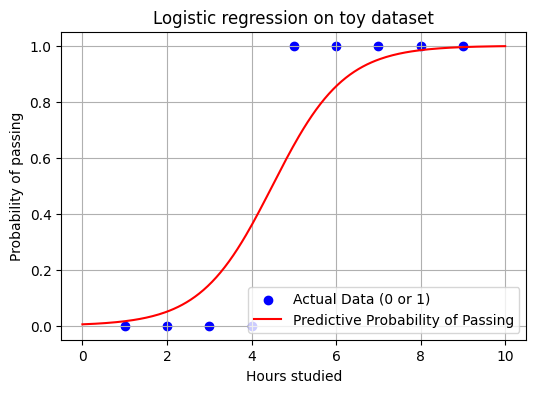

In [33]:
hours_grid = np.linspace(0, 10, 200).reshape(-1, 1)
pass_prob = toy_model.predict_proba(hours_grid)[:, 1]   

plt.figure(figsize=(6, 4))
plt.scatter(hours_studied, pass_exam, color='blue', label='Actual Data (0 or 1)')
plt.plot(hours_grid, pass_prob, color='red', label='Predictive Probability of Passing')
plt.xlabel("Hours studied")
plt.ylabel("Probability of passing")
plt.title("Logistic regression on toy dataset")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
# Predic for a few example student
example_hours = np.array([[2], [4], [6], [8]])
example_probs = toy_model.predict_proba(example_hours)[:, -1]
example_pred = toy_model.predict(example_hours)

results_df = pd.DataFrame(
    {
        "hours_studied": example_hours.flatten(),
        "Predicted_probablity_pass": np.round(example_probs, 4),
        "Predicted_class": example_pred
    }
)

results_df

,hours_studied,Predicted_probablity_pass,Predicted_class
0,2,0.0502,0
1,4,0.3582,0
2,6,0.8548,1
3,8,0.9842,1


# Sigmoid Function:  

The sigmoid function maps any real-valued number into the (0, 1) interval, making it ideal for binary classification problems. The output can be interpreted as a probability of belonging to the positive class. 

$$
\sigma (z) = \frac{1}{1 + e^{-z}}   
$$

where:
- $ z $ = input value
- $ e $ = base of the natural logarithm
- $\sigma(z)$ = output of the sigmoid function, representing the probability of the positive class



In [35]:
# Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Check some values
z_values = np.array([-5, -2, -1, 0, 1, 2, 5], dtype=float)
sigmoid_values = sigmoid(z_values)

sigmoid_df = pd.DataFrame({
    "z": z_values,
    "sigmoid(z)": np.round(sigmoid_values, 4)
})

sigmoid_df

,z,sigmoid(z)
0,-5.0,0.0067
1,-2.0,0.1192
2,-1.0,0.2689
3,0.0,0.5000
4,1.0,0.7311
5,2.0,0.8808
6,5.0,0.9933


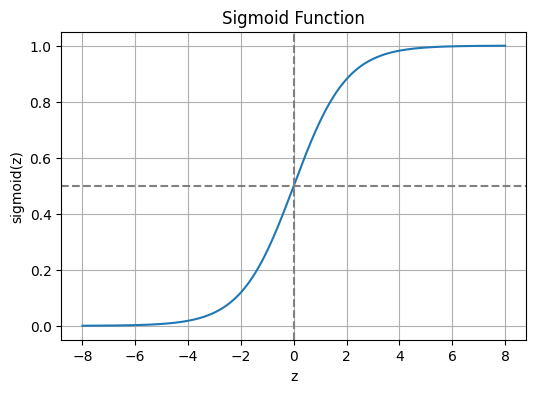

In [36]:
z_grid = np.linspace(-8, 8, 400)
sig_grid = sigmoid(z_grid)

plt.figure(figsize=(6, 4))
plt.plot(z_grid, sig_grid)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)

plt.axhline(0.5, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.show()

In [37]:
# Simple threshold demonstration 
probabilities = np.array([0.1, 0.3, 0.49, 0.5, 0.7, 0.9])
threshold = 0.5
predicted_classes = (probabilities >= threshold).astype(int)

threshold_df = pd.DataFrame({
    "Probability": probabilities,
    "Predicted_Class": predicted_classes
})

threshold_df

,Probability,Predicted_Class
0,0.10,0
1,0.30,0
2,0.49,0
3,0.50,1
4,0.70,1
5,0.90,1


**Notes:**

- Sigmoid function is a smooth S-shaped curve that takes any score and turns it into a probability.
- At z = 0, probability is 0.5, meaning the model is uncertain about the class.
- Values far below 0 map close to 0, and far above 0 is close to 1. 
- The model first gives score (z) based on the input features and weights, then applies sigmoid to get probability.


Probability Estimation:

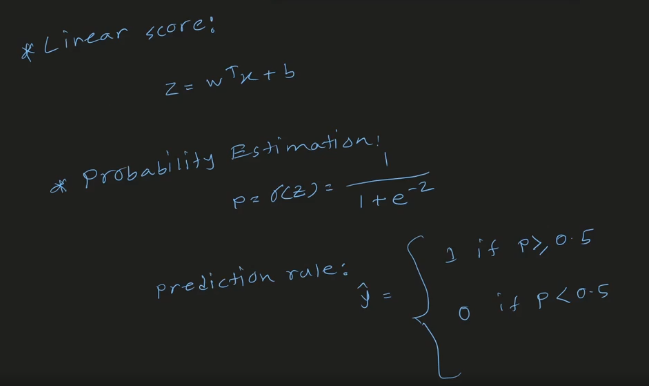

# 1️⃣ Linear Combination

First, logistic regression creates a linear equation like linear regression.

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

Where:

* $(x_1, x_2, ...)$ = input features
* $(\beta_0)$ = bias/intercept
* $(\beta_1, \beta_2, ...)$ = weights
* $(z)$ = raw score

This equation can produce any value:

* negative
* positive
* huge values

But probabilities must stay between 0 and 1.

So we need the sigmoid function.

---

# 2️⃣ Sigmoid Function

The sigmoid converts the raw score into probability.

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Output range:
* close to 0 → class 0
* close to 1 → class 1

---

# 3️⃣ Probability Interpretation

After applying sigmoid:

$$
P(Y=1|X)=\frac{1}{1+e^{-z}}
$$

This means:

> Probability that output belongs to class 1.

Example:

* 0.92 → 92% chance of class 1
* 0.08 → 8% chance of class 1

---

# 4️⃣ Decision Boundary

Usually:

* If probability ≥ 0.5 → predict class 1
* Else → predict class 0

Decision boundary:

$$
\sigma(z)=0.5
$$

Since sigmoid(0) = 0.5,
the boundary occurs when:

z=0

---

# 5️⃣ Log-Odds (Logit Function)

Logistic regression actually models the **log-odds**.

Odds:

$$
\text{Odds}=\frac{p}{1-p}
$$

Where:
Log-Odds:

$$
\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1x_1+\cdots+\beta_nx_n
$$
This transforms probabilities into a linear relationship.

---

# 6️⃣ Cost Function (Loss Function)

We need a way to measure prediction error.

Logistic regression uses **Log Loss / Cross Entropy Loss**.

For one sample:

$$
L = -\left(y\log(p)+(1-y)\log(1-p)\right)
$$

Where:

* $(y)$ = actual label
* $(p)$ = predicted probability

---

# 7️⃣ Optimization

The model adjusts weights to minimize loss.

This is done using:

* Gradient Descent
* Optimization algorithms

Weight update rule:

$$
\theta := \theta - \alpha \frac{\partial J}{\partial \theta}
$$

Where:


* $(\theta)$ = parameter
* $(\alpha)$ = learning rate
* $(J)$ = cost function

---

# 8️⃣ Maximum Likelihood Estimation (MLE)

Instead of minimizing squared error,
logistic regression tries to maximize probability of correct predictions.

This method is called:

* Maximum Likelihood Estimation

---

# 9️⃣ Geometry Intuition

Logistic regression creates a separating line/plane.

For:

* 2 features → line
* 3 features → plane
* higher dimensions → hyperplane

Equation:

$$
\beta_0 + \beta_1x_1 + \beta_2x_2 = 0
$$
---

# 🔥 Main Mathematical Concepts Summary

| Concept            | Purpose                   |
| ------------------ | ------------------------- |
| Linear Equation    | Combine features          |
| Sigmoid Function   | Convert to probability    |
| Probability        | Predict class confidence  |
| Log-Odds           | Make relation linear      |
| Cross Entropy Loss | Measure error             |
| Gradient Descent   | Optimize weights          |
| MLE                | Best parameter estimation |
| Hyperplane         | Decision boundary         |

---


**Binary Cross Entropy (BCE)** is a loss function used for **binary classification problems**.

It measures:

> how far the predicted probability is from the actual answer.

It is heavily used in:

* Logistic Regression
* Binary Neural Network Classification
* Deep Learning

---

# 📐 Binary Cross Entropy Formula

$L = -\left(y\log(p) + (1-y)\log(1-p)\right)$

Where:

* $(y)$ = actual label

  * 0 or 1
* $(p)$ = predicted probability
* $(L)$ = loss

---

# 🧠 Intuition

The loss becomes:

* **small** when prediction is correct
* **large** when prediction is wrong

---

# ✅ Case 1 — Correct Prediction

Suppose:

* Actual = 1
* Predicted = 0.99

Then loss is very small.

The model is rewarded.

---

# ❌ Case 2 — Wrong Prediction

Suppose:

* Actual = 1
* Predicted = 0.01

Then:

$
\log(0.01)
$

becomes a large negative value.

After the minus sign, the loss becomes huge.

The model is strongly punished.

---

# 🔍 Two Separate Cases

## When (y=1)

Formula becomes:

$L = -\log(p)$

The model wants:

* $(p \to 1)$

---

## When (y=0)

Formula becomes:

$L = -\log(1-p)$

The model wants:

* $(p \to 0)$

---

# 📊 Example Calculation

Suppose:

* Actual label = 1
* Predicted probability = 0.8

Loss:

$L = -\log(0.8) \approx 0.223$

Small loss → good prediction.

---

Suppose:

* Actual label = 1
* Predicted probability = 0.1

Loss:

$L = -\log(0.1) \approx 2.302$

Large loss → bad prediction.

---

# 📈 Why BCE is Better than MSE for Classification

Using Mean Squared Error can make learning slow for probabilities.

Binary Cross Entropy:

* gives better gradients
* learns faster
* works naturally with probabilities

That’s why logistic regression uses BCE.

---

# 🔥 In Logistic Regression

Pipeline:

1. Linear equation
2. Sigmoid function
3. Probability output
4. Binary Cross Entropy computes error
5. Gradient descent updates weights

---

# 🧩 BCE for Multiple Samples

For (N) samples:

$J = -\frac{1}{N}\sum_{i=1}^{N}\left(y_i\log(p_i)+(1-y_i)\log(1-p_i)\right)$

Where:
* $(N)$ = number of samples
* $(y_i)$ = actual label for sample i
* $(p_i)$ = predicted probability for sample i
* $(J)$	 = average loss over the dataset
  

This is the average BCE loss over the dataset.

---

# 🧠 Simple Intuition

Binary Cross Entropy asks:

> “How wrong was the predicted probability?”

* confident correct prediction → tiny loss
* confident wrong prediction → huge loss


# Logistic Regression on a Real Dataset

In [38]:
data = load_breast_cancer()
X_full = data.data
y_full = data.target

print("Feature matrix shape: ", X_full.shape)
print("Target vector shape: ", y_full.shape)
print("Classes: ", data.target_names)

Feature matrix shape:  (569, 30)
Target vector shape:  (569,)
Classes:  ['malignant' 'benign']


In [39]:
feature_names = data.feature_names
df = pd.DataFrame(X_full, columns=feature_names)
df["target"] = y_full
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [40]:
df.describe().T.head(15)        

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.37000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.84000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.24000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.10000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.09587,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.09263,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.06154,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.03350,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.17920,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.06154,0.066120,0.09744


In [41]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.metrics import accuracy_score

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_test_pred = clf.predict(X_test_scaled)
y_test_proba = clf.predict_proba(X_test_scaled)[:, 1] 


print("Test accuracy: ", accuracy_score(y_test, y_test_pred))

Test accuracy:  0.9736842105263158


In [44]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[41  2]
 [ 1 70]]


In [45]:
print("Classification Report:\n", classification_report(y_test, y_test_pred, target_names=data.target_names))

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**What classification report is:**

- Precision: Proportion of positive identifications that were actually correct.
- Recall: Proportion of actual positives that were identified correctly.
- F1-Score: Harmonic mean of precision and recall, providing a balance between the two.
- Support: Number of actual occurrences of the class in the dataset.


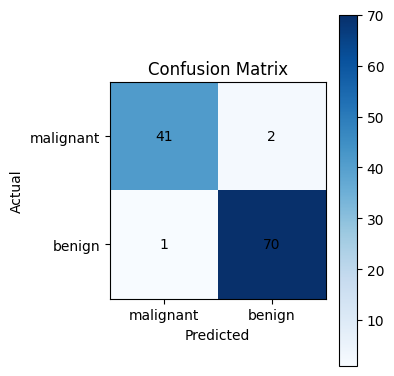

In [46]:
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
tick_labels = data.target_names

plt.xticks(ticks=[0, 1], labels=tick_labels)
plt.yticks(ticks=[0, 1], labels=tick_labels)   

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

## Evaluation Metrics and Threshold Effects


In [47]:
from sklearn.metrics import recall_score, precision_score, f1_score


# Basic metrics at default threshold of 0.5
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1-Score: 0.9790


In [48]:
# Trying different thresholds
thresholds = np.linspace(0.1, 0.9, 9)
rows = []

for thresh in thresholds:
    y_thr_pred = (y_test_proba >= thresh).astype(int)
    acc_thr =  accuracy_score(y_test, y_thr_pred)
    prec_thr = precision_score(y_test, y_thr_pred)
    rec_thr = recall_score(y_test, y_thr_pred)
    f1_thr = f1_score(y_test, y_thr_pred)
    rows.append({
        "thr": thresh,
        "accuracy_thr": acc_thr,
        "precision_thr": prec_thr,
        "recall_thr": rec_thr,
        "f1_thr": f1_thr
    })

thr_df = pd.DataFrame(rows)
print(thr_df)

   thr  accuracy_thr  precision_thr  recall_thr    f1_thr
0  0.1      0.956140       0.934211    1.000000  0.965986
1  0.2      0.973684       0.959459    1.000000  0.979310
2  0.3      0.982456       0.972603    1.000000  0.986111
3  0.4      0.982456       0.972603    1.000000  0.986111
4  0.5      0.973684       0.972222    0.985915  0.979021
5  0.6      0.982456       0.985915    0.985915  0.985915
6  0.7      0.956140       0.985294    0.943662  0.964029
7  0.8      0.956140       0.985294    0.943662  0.964029
8  0.9      0.929825       0.984615    0.901408  0.941176


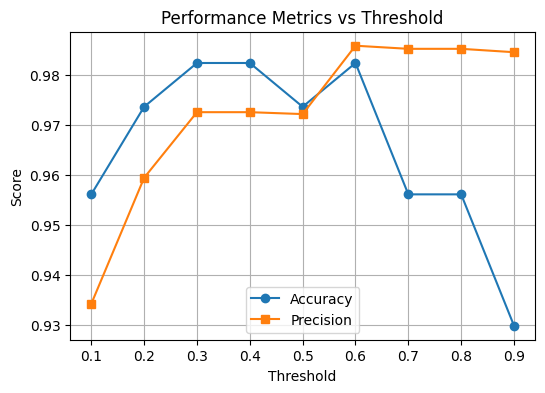

In [49]:
plt.figure(figsize=(6, 4))
plt.plot(thr_df["thr"], thr_df["accuracy_thr"], label="Accuracy", marker='o')
plt.plot(thr_df["thr"], thr_df["precision_thr"], label="Precision", marker='s')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Performance Metrics vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

## Improving Model with L2 Regularization

In [53]:
# Two models with different regularization strengths
clf_weak = LogisticRegression(C=1000, max_iter=1000)
clf_strong = LogisticRegression(C=0.01, max_iter=1000)


clf_weak.fit(X_train_scaled, y_train)
clf_strong.fit(X_train_scaled, y_train)

y_pred_weak = clf_weak.predict(X_test_scaled)
y_pred_strong = clf_strong.predict(X_test_scaled)

# print("Weak Regularization (C=1000) - Classification Report:\n", classification_report(y_test, y_pred_weak, target_names=data.target_names))
# print("Strong Regularization (C=0.01) - Classification Report:\n", classification_report(y_test, y_pred_strong, target_names=data.target_names))

# Print accuracy for both models
acc_weak = accuracy_score(y_test, y_pred_weak)
acc_strong = accuracy_score(y_test, y_pred_strong)
print(f"Weak Regularization (C=1000) - Accuracy: {acc_weak:.4f}")
print(f"Strong Regularization (C=0.01) - Accuracy: {acc_strong:.4f}")

Weak Regularization (C=1000) - Accuracy: 0.9386
Strong Regularization (C=0.01) - Accuracy: 0.9649


In [55]:
# Compare coefficient magnitudes
coef_weak = np.abs(clf_weak.coef_).flatten()
coef_strong = np.abs(clf_strong.coef_).flatten()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coef_Weak": coef_weak,
    "Coef_Strong": coef_strong
})

coef_df.sort_values("Coef_Weak", ascending=False).head(10)

,Feature,Coef_Weak,Coef_Strong
5,mean compactness,31.482891,0.092693
10,radius error,27.671557,0.152178
7,mean concave points,27.006679,0.217539
16,concavity error,16.800449,0.025690
28,worst symmetry,15.459713,0.174270
26,worst concavity,15.006672,0.172557
6,mean concavity,14.454350,0.159946
23,worst area,13.455873,0.206081
19,fractal dimension error,13.031365,0.083212
12,perimeter error,12.873922,0.128844


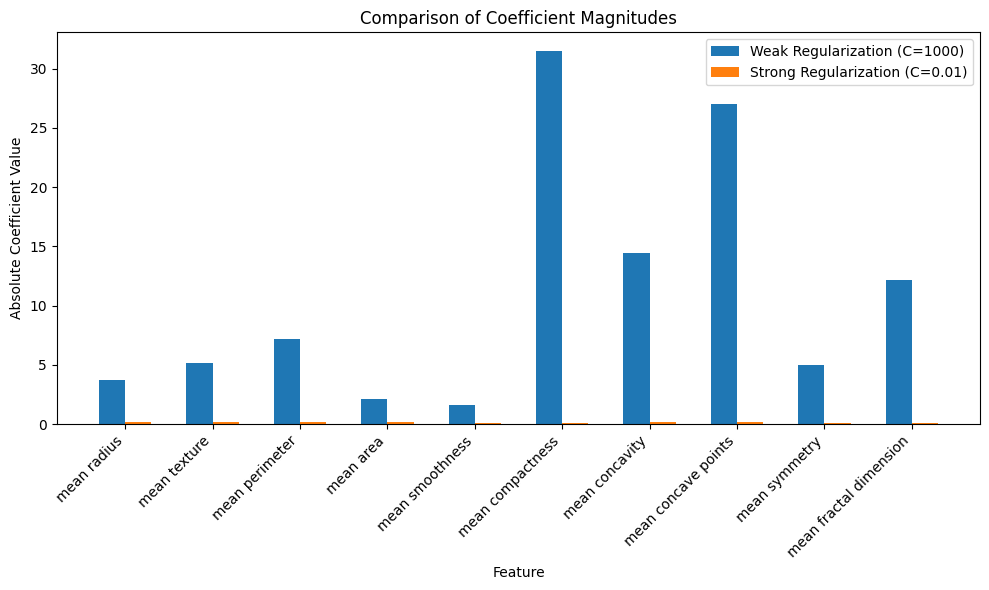

In [57]:
# Plot absolute values for the first 10 Coefficients for both models.
n_plot = 10
indices = np.arange(n_plot)

plt.figure(figsize=(10, 6))
plt.bar(indices - 0.15, np.abs(clf_weak.coef_).flatten()[:n_plot], width=0.3, label='Weak Regularization (C=1000)')
plt.bar(indices + 0.15, np.abs(clf_strong.coef_).flatten()[:n_plot], width=0.3, label='Strong Regularization (C=0.01)')
plt.xlabel('Feature')
plt.ylabel('Absolute Coefficient Value')
plt.title('Comparison of Coefficient Magnitudes')
plt.xticks(indices, feature_names[:n_plot], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()